# Reviewing ECMWF, ERA5 data for OND, JJAS and MAM

This notebook reviews the rainfall data for the 3 seasons and looks at the driest years to get years to calibrate the trigger against.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
from src.constants import *
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from affine import Affine
from rasterstats import zonal_stats
import calendar
import re

In [3]:
pd.options.display.float_format = "{:,.0f}".format

In [4]:
ond_blob_name = "ds-aa-eth-drought/exploration/Ethiopia OND zones.csv"
mam_blob_name = "ds-aa-eth-drought/exploration/Ethiopia MAM zones.csv"
jjas_blob_name = "ds-aa-eth-drought/exploration/Ethiopia JJAS zones.csv"
ond_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data OND.csv"
)
mam_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data MAM.csv"
)
jjas_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data JJAS.csv"
)
# maproom hindcasts
somali_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - Somali Region.csv"
somali_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA OND Trigger Documentation and Metrics - Somali Region.csv"
oromia_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP FbF Ethiopia 2023 MAM Trigger Documentation and Metrics - Oromia Region.csv"
oromia_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - Oromia Region (1).csv"
south_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - South Ethiopia Region.csv"
south_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - South Ethiopia Region.csv"
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-12-01")
ond_months = [10, 11, 12]
mam_months = [3, 4, 5]
jjas_months = [6, 7, 8, 9]

In [5]:
# plot the admin bounds for each season
eth_adm2 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=2)
eth_adm1 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=1)
eth_adm0 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=0)

In [6]:
eth_adm2_aea = eth_adm2.to_crs(
    "+proj=aea +lat_1=20 +lat_2=-23 +lat_0=0 +lon_0=25 +datum=WGS84 +units=m +no_defs"
)
eth_adm2["area_km2"] = eth_adm2_aea.geometry.area / 1e6
adm2_area = eth_adm2[["adm2_src", "area_km2"]].rename(
    columns={"adm2_src": "adm2_pcode"}
)

In [7]:
# make a function to run the code below for each season
def analyze_season(blob_name, season_name, season_months):
    season_csv = stratus.load_csv_from_blob(
        blob_name, stage="dev", container_name="projects"
    )
    season_csv = season_csv.merge(adm2_area, on="adm2_pcode", how="left")
    # Fetch ERA5 data for the specified woredas and date range
    seasonal_rainfall = fetch_era5_data(
        season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
    )
    # adding month to the seasonal_rainfall dataframe for easier analysis
    seasonal_rainfall["month"] = pd.to_datetime(
        seasonal_rainfall["valid_date"]
    ).dt.month
    seasonal_rainfall["year"] = pd.to_datetime(seasonal_rainfall["valid_date"]).dt.year
    seasonal_rainfall = seasonal_rainfall.merge(
        season_csv[["adm2_pcode", "area_km2"]],
        left_on="pcode",
        right_on="adm2_pcode",
        how="left",
    )
    # extracting values for only the season months
    seasonal_rainfall_months = seasonal_rainfall[
        seasonal_rainfall["month"].isin(season_months)
    ].copy()
    seasonal_rainfall_months.loc[:, "month_name"] = seasonal_rainfall_months[
        "month"
    ].apply(lambda m: calendar.month_abbr[m])
    # summing the mean column by year for all adm2_pcode
    # seasonal_rainfall_summed = (
    #    seasonal_rainfall_months.groupby(["month", "year"])["mean"].mean().reset_index()
    # )
    seasonal_rainfall_summed = (
        seasonal_rainfall_months.groupby(["month", "year"])
        .apply(
            lambda g: np.average(g["mean"], weights=g["area_km2"]), include_groups=False
        )
        .reset_index(name="mean")
    )

    seasonal_rainfall_summed["mean"] = seasonal_rainfall_summed[
        "mean"
    ] * seasonal_rainfall_summed["month"].map(days_in_month)
    # plot the values as a bar chart
    # stack the values yearly and color each month differently
    # add total values on top of each bar

    fig, ax = plt.subplots(figsize=(12, 4))
    months = seasonal_rainfall_summed["month"].unique()
    bottom = None
    for month in months:
        month_data = seasonal_rainfall_summed[
            seasonal_rainfall_summed["month"] == month
        ]
        ax.bar(
            month_data["year"],
            month_data["mean"],
            bottom=bottom,
            label=calendar.month_abbr[month],
            alpha=0.6,
        )
        if bottom is None:
            bottom = month_data["mean"].values
        else:
            bottom += month_data["mean"].values
    for i, year in enumerate(seasonal_rainfall_summed["year"].unique()):
        total = seasonal_rainfall_summed[seasonal_rainfall_summed["year"] == year][
            "mean"
        ].sum()
        ax.text(year, total + 2, f"{total:.0f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(f"Seasonal Rainfall ({season_name}) by Year - Area Weighted Average")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total Rainfall (mm)")
    ax.legend(title="Month")
    plt.show()

In [8]:
analyze_season(mam_blob_name, "MAM", mam_months)
analyze_season(jjas_blob_name, "JJAS", jjas_months)
analyze_season(ond_blob_name, "OND", ond_months)

ClientAuthenticationError: Server failed to authenticate the request. Make sure the value of Authorization header is formed correctly including the signature.
RequestId:5fe02c06-301e-0010-7ee4-9fd092000000
Time:2026-02-17T08:08:37.3021285Z
ErrorCode:AuthenticationFailed
authenticationerrordetail:Signature did not match. String to sign used was imb0chd0dev
rl
bfqt
sco
2025-02-17T19:33:42Z
2026-02-18T03:33:42Z

https
2022-11-02


Content: <?xml version="1.0" encoding="utf-8"?><Error><Code>AuthenticationFailed</Code><Message>Server failed to authenticate the request. Make sure the value of Authorization header is formed correctly including the signature.
RequestId:5fe02c06-301e-0010-7ee4-9fd092000000
Time:2026-02-17T08:08:37.3021285Z</Message><AuthenticationErrorDetail>Signature did not match. String to sign used was imb0chd0dev
rl
bfqt
sco
2025-02-17T19:33:42Z
2026-02-18T03:33:42Z

https
2022-11-02

</AuthenticationErrorDetail></Error>

In [ ]:
# adding population weighting option
# zonal stats using worldpop population data
worldpop_path = "ds-aa-eth-drought/raw/worldpop/eth_pop_2025_CN_1km_R2025A_UA_v1.tif"
# read in tif file
worldpop_da = stratus.open_blob_cog(
    worldpop_path,
    stage="dev",
    container_name="projects",
    chunks=None,
    container_client=None,
)
da2 = worldpop_da.sel(band=1)
arr = da2.values
x = da2["x"].values
y = da2["y"].values
res_x = x[1] - x[0]
res_y = y[0] - y[1]
transform = Affine(res_x, 0, x.min() - res_x / 2, 0, -res_y, y.max() + res_y / 2)
nodata = da2.attrs.get("_FillValue", None)

# compute zonal stats
zs_adm2 = zonal_stats(
    eth_adm2.geometry,
    arr,
    affine=transform,
    stats=["sum", "mean"],
    nodata=nodata,
    all_touched=True,
)
zs_df = pd.DataFrame(zs_adm2)
eth_adm2_pop = pd.concat(
    [eth_adm2.reset_index(drop=True), zs_df.reset_index(drop=True)], axis=1
)
stratus.upload_csv_to_blob(
    eth_adm2_pop.drop(columns="geometry"),
    "ds-aa-eth-drought/processed/eth_adm2_pop.csv",
    stage="dev",
    container_name="projects",
)
eth_adm2_pop["sum"].sum()

137218095.7890625

In [ ]:
eth_adm2_pop.columns

Index(['fid', 'adm2_id', 'adm2_src', 'adm2_name', 'adm2_name1', 'adm2_name2',
       'adm1_id', 'adm1_src', 'adm1_name', 'adm1_name1', 'adm1_name2',
       'adm0_id', 'adm0_src', 'adm0_name', 'adm0_name1', 'adm0_name2',
       'src_lvl', 'src_lang', 'src_lang1', 'src_lang2', 'src_date',
       'src_update', 'src_name', 'src_name1', 'src_lic', 'src_url', 'src_grp',
       'iso_cd', 'iso_2', 'iso_3', 'iso_3_grp', 'region3_cd', 'region3_nm',
       'region2_cd', 'region2_nm', 'region1_cd', 'region1_nm', 'status_cd',
       'status_nm', 'wld_date', 'wld_update', 'wld_view', 'wld_notes',
       'geometry', 'area_km2', 'mean', 'sum'],
      dtype='object')

In [ ]:
def build_season_table(
    seas5_data,
    validation_csv,
    era5_data,
    season_name,
    season_months,
    lead_time_map,
    rp_threshold=5,
    val_cols=("CERF Allocations", "People Affected"),
    plot_heatmap=False,
    plot_skill=False,
    highlight_value=None,
    N_events=7,
    pop_df=eth_adm2_pop,
):
    df = seas5_data.copy()
    all_years = list(range(1997, 2026))
    df["issued_month"] = pd.to_datetime(df["issued_date"]).dt.month
    df["valid_month"] = pd.to_datetime(df["valid_date"]).dt.month
    df["valid_year"] = pd.to_datetime(df["valid_date"]).dt.year

    df = df[
        (df["valid_month"].isin(season_months))
        & (df["issued_month"].isin(lead_time_map.keys()))
    ].copy()
    df["mean"] = df["mean"] * df["valid_month"].map(days_in_month)

    df = df.groupby(["pcode", "valid_year", "issued_month"])["mean"].sum().reset_index()
    df["lead_time"] = df["issued_month"].map(lead_time_map)

    df["rank"] = df.groupby(["pcode", "issued_month"])["mean"].rank(
        method="min", ascending=True
    )
    n = df["valid_year"].nunique()
    df["return_period"] = ((n + 1) / df["rank"]).round(1)
    if pop_df is not None:
        df = df.merge(
            pop_df[["adm2_src", "sum"]],
            left_on="pcode",
            right_on="adm2_src",
            how="left",
        )

    df_rp = df[df["return_period"] >= rp_threshold].copy()

    if pop_df is not None:
        drought_counts = (
            df_rp.groupby(["valid_year", "lead_time"])["sum"]
            .sum()
            .reset_index(name="count")
        )
    else:
        drought_counts = (
            df_rp.groupby(["valid_year", "lead_time"]).size().reset_index(name="count")
        )

    era = era5_data.copy()
    era["valid_month"] = pd.to_datetime(era["valid_date"]).dt.month
    era["valid_year"] = pd.to_datetime(era["valid_date"]).dt.year

    era = era[era["valid_month"].isin(season_months)].copy()
    era["mean"] = era["mean"] * era["valid_month"].map(days_in_month)

    era = era.groupby(["pcode", "valid_year"])["mean"].sum().reset_index()

    era["rank"] = era.groupby("pcode")["mean"].rank(method="min", ascending=True)
    n2 = era["valid_year"].nunique()
    era["return_period"] = ((n2 + 1) / era["rank"]).round(1)

    if pop_df is not None:
        era = era.merge(
            pop_df[["adm2_src", "sum"]],
            left_on="pcode",
            right_on="adm2_src",
            how="left",
        )

    era_rp = era[era["return_period"] >= rp_threshold].copy()

    if pop_df is not None:
        era_drought = (
            era_rp.groupby("valid_year")["sum"].sum().reset_index(name="count")
        )
    else:
        era_drought = era_rp.groupby("valid_year").size().reset_index(name="count")

    era_drought["lead_time"] = 0
    combined = pd.concat([drought_counts, era_drought], ignore_index=True)
    table = combined.pivot_table(
        index="valid_year",
        columns="lead_time",
        values="count",
        fill_value="",
    ).reset_index()

    table = table.merge(
        validation_csv, left_on="valid_year", right_on="year", how="outer"
    )
    table = table.drop_duplicates(subset=["year"], keep="first")
    table = table.set_index("year").reindex(all_years).reset_index()
    era_rain = era.groupby("valid_year")["mean"].mean().reset_index()
    era_rain = era_rain.rename(columns={"mean": "ERA5 Rainfall (mm)"})
    table = table.merge(era_rain, left_on="year", right_on="valid_year", how="outer")
    rename_map = {}
    for issued_month, lt in lead_time_map.items():
        rename_map[lt] = (
            f"Zones ≥ 5-Year RP LT-{lt} ({calendar.month_abbr[issued_month]})"
        )
    rename_map[0] = "Zones ≥ 5-Year RP (Observed)"

    table = table.rename(columns=rename_map)
    for col in ["valid_year", "Season", "season", "Season_x", "Season_y"]:
        if col in table.columns:
            table = table.drop(columns=[col])

    table = table.apply(
        lambda col: (
            col.round(0)
            if col.dtype in ("float64", "float32", "int64", "int32")
            else col
        )
    )

    table = table.replace(np.nan, "")

    lt_cols = [c for c in table.columns if c.startswith("Zones ≥ 5-Year RP LT-")]
    lt_sorted = sorted(
        lt_cols, key=lambda x: int(re.search(r"LT-(\d+)", x).group(1)), reverse=True
    )

    final_cols = (
        ["year", "ERA5 Rainfall (mm)"]
        + lt_sorted
        + ["Zones ≥ 5-Year RP (Observed)"]
        + list(val_cols)
    )
    final_cols = [c for c in final_cols if c in table.columns]

    table = table[final_cols]
    # order table by ERA5 Rainfall (mm)
    table = table.drop_duplicates(subset=["year"], keep="first")
    table = table.set_index("year").reindex(all_years).reset_index()
    table = table.rename(columns={"index": "year"})
    table["ERA5 Rainfall (mm)"] = pd.to_numeric(
        table["ERA5 Rainfall (mm)"], errors="coerce"
    )
    table = table.sort_values("ERA5 Rainfall (mm)")
    table = table.replace(np.nan, "")
    # table.rename(columns={"ERA5 Rainfall (mm)": "ERA5 Rainfall (mm)"}, inplace=True)

    fmt_val_cols = list(val_cols)
    if pop_df is not None:
        fmt_val_cols = fmt_val_cols + lt_cols + ["Zones ≥ 5-Year RP (Observed)"]

    non_val_cols = [c for c in final_cols if c not in fmt_val_cols]
    for c in non_val_cols:
        if c in table.columns:
            table[c] = table[c].apply(
                lambda x: f"{x:.0f}" if isinstance(x, (int, float)) else x
            )
    for c in fmt_val_cols:
        if c in table.columns:
            table[c] = table[c].apply(
                lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x
            )

    if plot_heatmap:
        pivot = combined.pivot(index="lead_time", columns="valid_year", values="count")

        pivot = pivot.reindex(columns=all_years)
        pivot = pivot.reindex(sorted(pivot.index, reverse=True))

        lt_map = {lt: calendar.month_abbr[m] for m, lt in lead_time_map.items()}
        lt_map[0] = "ERA5"
        pivot.index = pivot.index.map(lt_map)

        plt.figure(figsize=(15, 4))

        if pop_df is not None:
            annot = pivot.map(lambda x: f"{x/1e6:.0f}" if pd.notnull(x) else "")
            fmt = ""
            cbar_label = "People affected (millions)"
            title_metric = "Population in Zones"
        else:
            annot = True
            fmt = "g"
            cbar_label = "Number of zones"
            title_metric = "Number of Zones"

        ax = sns.heatmap(
            pivot,
            annot=annot,
            fmt=fmt,
            cmap="Reds",
            cbar_kws={"label": cbar_label},
        )

        # 🔹 format colorbar ticks in millions
        if pop_df is not None:
            cbar = ax.collections[0].colorbar
            cbar.formatter = FuncFormatter(lambda x, _: f"{x/1e6:.0f}")
            cbar.update_ticks()

        plt.title(
            f"{title_metric} drier than 1-in-{rp_threshold}yr RP — "
            f"{season_name} Season (SEAS5 + ERA5)"
        )
        plt.xlabel("Valid Year")
        plt.ylabel("Source / Lead Time")
        plt.tight_layout()
        plt.show()

    if plot_skill:

        fcst_only = combined[combined["lead_time"] != 0].copy()
        lts = sorted(fcst_only["lead_time"].unique(), reverse=True)

        max_val = int(fcst_only["count"].max())

        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
        axes = axes.flatten()

        for ax, lt in zip(axes, lts):

            df_lt = fcst_only[fcst_only["lead_time"] == lt]
            years = sorted(all_years)

            if pop_df is not None:
                thresholds = np.arange(1e6, max_val + 1e6, 1e6)
            else:
                thresholds = np.arange(1, max_val + 1)

            hit_rates, false_rates, miss_rates = [], [], []

            for T in thresholds:

                fc = (
                    df_lt.set_index("valid_year")["count"]
                    .reindex(years)
                    .fillna(0)
                    .apply(lambda z: 1 if z >= T else 0)
                )

                era_rain = era.groupby("valid_year")["mean"].sum().reset_index()
                era_rain["rank"] = era_rain["mean"].rank(method="first", ascending=True)

                obs = (
                    era_rain.set_index("valid_year")["rank"]
                    .reindex(all_years)
                    .fillna(np.inf)
                    .apply(lambda r: 1 if r <= N_events else 0)
                )

                hits = ((fc == 1) & (obs == 1)).sum()
                misses = ((fc == 0) & (obs == 1)).sum()
                false_alarms = ((fc == 1) & (obs == 0)).sum()
                correct_neg = ((fc == 0) & (obs == 0)).sum()

                HR = hits / (hits + misses) if (hits + misses) > 0 else 0
                FAR = (
                    false_alarms / (false_alarms + correct_neg)
                    if (false_alarms + correct_neg) > 0
                    else 0
                )
                MR = misses / (hits + misses) if (hits + misses) > 0 else 0

                hit_rates.append(HR)
                false_rates.append(FAR)
                miss_rates.append(MR)

            if highlight_value is not None:
                T = (
                    highlight_value * 1e6
                    if pop_df is not None
                    else int(highlight_value)
                )

                if T in thresholds:
                    idx = list(thresholds).index(T)

                    ax.axvline(T, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

                    ax.scatter(T, hit_rates[idx], color="black", s=60)
                    ax.scatter(T, false_rates[idx], color="black", s=60)
                    ax.scatter(T, miss_rates[idx], color="black", s=60)

                    ax.text(T * 1.02, hit_rates[idx], f"HR={hit_rates[idx]:.2f}")
                    ax.text(T * 1.02, false_rates[idx], f"FAR={false_rates[idx]:.2f}")
                    ax.text(T * 1.02, miss_rates[idx], f"MR={miss_rates[idx]:.2f}")

            ax.plot(thresholds, hit_rates, label="Hit Rate", linewidth=2)
            ax.plot(thresholds, false_rates, label="False Alarm Rate", linewidth=2)
            ax.plot(thresholds, miss_rates, label="Miss Rate", linewidth=2)

            issued_month = [m for m, l in lead_time_map.items() if l == lt][0]
            ax.set_title(f"Issued in {calendar.month_abbr[issued_month]}")
            ax.grid(alpha=0.3)

            if pop_df is not None:
                ax.xaxis.set_major_formatter(
                    FuncFormatter(lambda x, _: f"{int(x/1e6)}")
                )

        fig.add_subplot(111, frameon=False)
        plt.tick_params(
            labelcolor="none", top=False, bottom=False, left=False, right=False
        )

        plt.xlabel(
            "Threshold (Population, millions)"
            if pop_df is not None
            else "Threshold (Number of Zones)"
        )
        plt.ylabel("Metric Value")

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=3)

        plt.tight_layout()
        plt.show()

    if highlight_value is not None:

        T = highlight_value * 1e6 if pop_df is not None else int(highlight_value)
        total_years = len(all_years)
        rows = []

        fcst_only = combined[combined["lead_time"] != 0].copy()

        for lt in sorted(fcst_only["lead_time"].unique(), reverse=True):

            df_lt = fcst_only[fcst_only["lead_time"] == lt]

            activated_years = df_lt[df_lt["count"] >= T]["valid_year"].nunique()

            rp = (
                round(total_years / activated_years, 1)
                if activated_years > 0
                else float("inf")
            )

            issued_month = [m for m, l in lead_time_map.items() if l == lt][0]
            issued_label = calendar.month_abbr[issued_month]

            rows.append(
                {
                    "Source": "SEAS5",
                    "Lead Time": issued_label,
                    "Years Activated": int(activated_years),
                    "Total Years": total_years,
                    "Return Period (yr)": rp,
                }
            )

        era_activated_years = era_drought[era_drought["count"] >= T][
            "valid_year"
        ].nunique()

        era_rp = (
            round(total_years / era_activated_years, 1)
            if era_activated_years > 0
            else float("inf")
        )

        rows.append(
            {
                "Source": "ERA5",
                "Lead Time": "Observed",
                "Years Activated": int(era_activated_years),
                "Total Years": total_years,
                "Return Period (yr)": era_rp,
            }
        )

        overall_activated_years = combined[
            (combined["lead_time"] != 0) & (combined["count"] >= T)
        ]["valid_year"].nunique()

        overall_rp = (
            round(total_years / overall_activated_years, 1)
            if overall_activated_years > 0
            else float("inf")
        )

        rows.append(
            {
                "Source": "SEAS5",
                "Lead Time": "Overall",
                "Years Activated": int(overall_activated_years),
                "Total Years": total_years,
                "Return Period (yr)": overall_rp,
            }
        )

        summary_df = pd.DataFrame(rows)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.axis("off")

        tbl = ax.table(
            cellText=summary_df.values,
            colLabels=summary_df.columns,
            loc="center",
        )

        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 1.6)

        for (row, col), cell in tbl.get_celld().items():
            if row == 0:
                cell.set_text_props(weight="bold")
                cell.set_facecolor("#f0f0f0")

        title_unit = "million (Population)" if pop_df is not None else "Zones"
        ax.set_title(
            f"Empirical return period by lead time — threshold = {highlight_value} {title_unit}",
            pad=10,
        )

        plt.tight_layout()
        plt.show()

    if highlight_value is not None:  # reuse N_events, ignore highlight_value itself

        drought_cols = [
            c
            for c in table.columns
            if c.startswith("Zones ≥ 5-Year RP LT-")
            or c == "Zones ≥ 5-Year RP (Observed)"
        ]

        # convert to numeric for ranking
        numeric_table = table.copy()
        for c in drought_cols:
            numeric_table[c] = (
                table[c]
                .replace("", np.nan)
                .astype(str)
                .str.replace(",", "", regex=False)
                .astype(float)
            )

        def highlight_top_n(col):
            col_num = numeric_table[col.name]
            top_n_idx = col_num.nlargest(N_events).index
            return [
                "background-color: red" if i in top_n_idx else "" for i in col.index
            ]

        styled = table.style.apply(
            highlight_top_n,
            subset=drought_cols,
            axis=0,
        )

        return styled

    return table

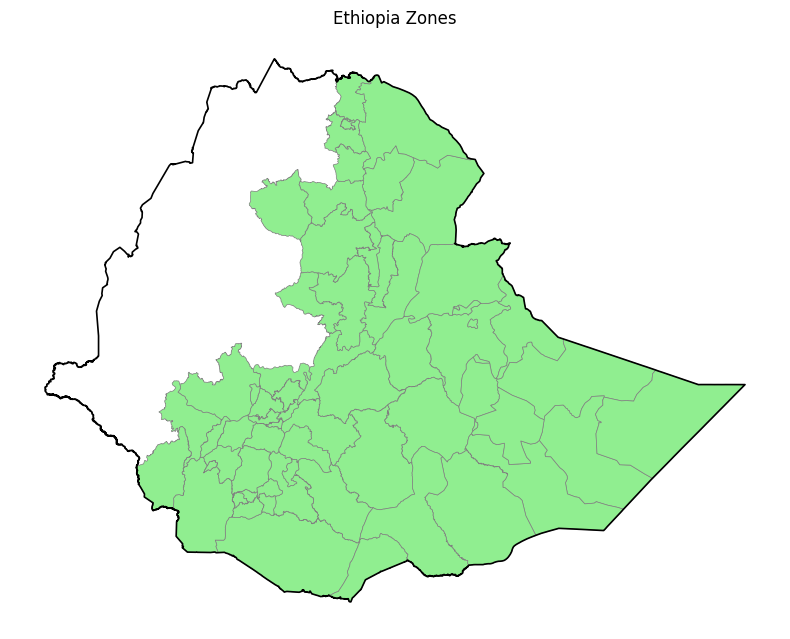

In [ ]:
season_csv = stratus.load_csv_from_blob(
    mam_blob_name, stage="dev", container_name="projects"
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
era5_df = era5_data.copy()
era5_df["valid_month"] = pd.to_datetime(era5_df["valid_date"]).dt.month
era5_df["mean"] = era5_data["mean"] * era5_df["valid_month"].map(days_in_month)
season_months = [3, 4, 5]
era5_seasonal = era5_df[
    (era5_df["valid_month"].isin(season_months))
    & (era5_df["pcode"].isin(season_csv["adm2_pcode"].unique()))
].copy()
# sum grouping by pcode and year
era5_seasonal = (
    era5_seasonal.groupby(["pcode", "year"])["mean"]
    .sum()
    .groupby("pcode")
    .mean()
    .reset_index()
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
# seas5_data = seas5_data[
#    seas5_data["pcode"].isin(era5_seasonal[era5_seasonal["mean"] >= 150]["pcode"])
# ].copy()
# era5_data = era5_data[
#    era5_data["pcode"].isin(era5_seasonal[era5_seasonal["mean"] >= 150]["pcode"])
# ].copy()
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    mam_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(seas5_data["pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

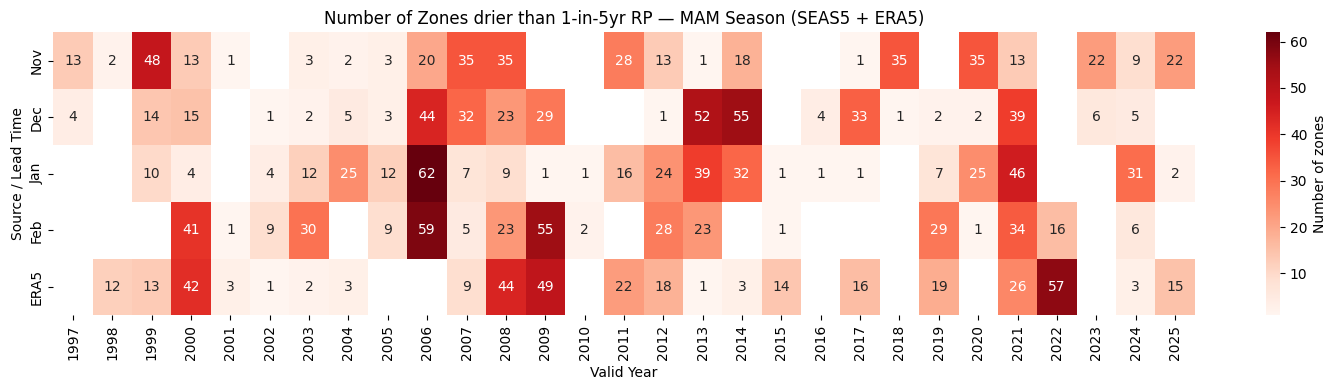

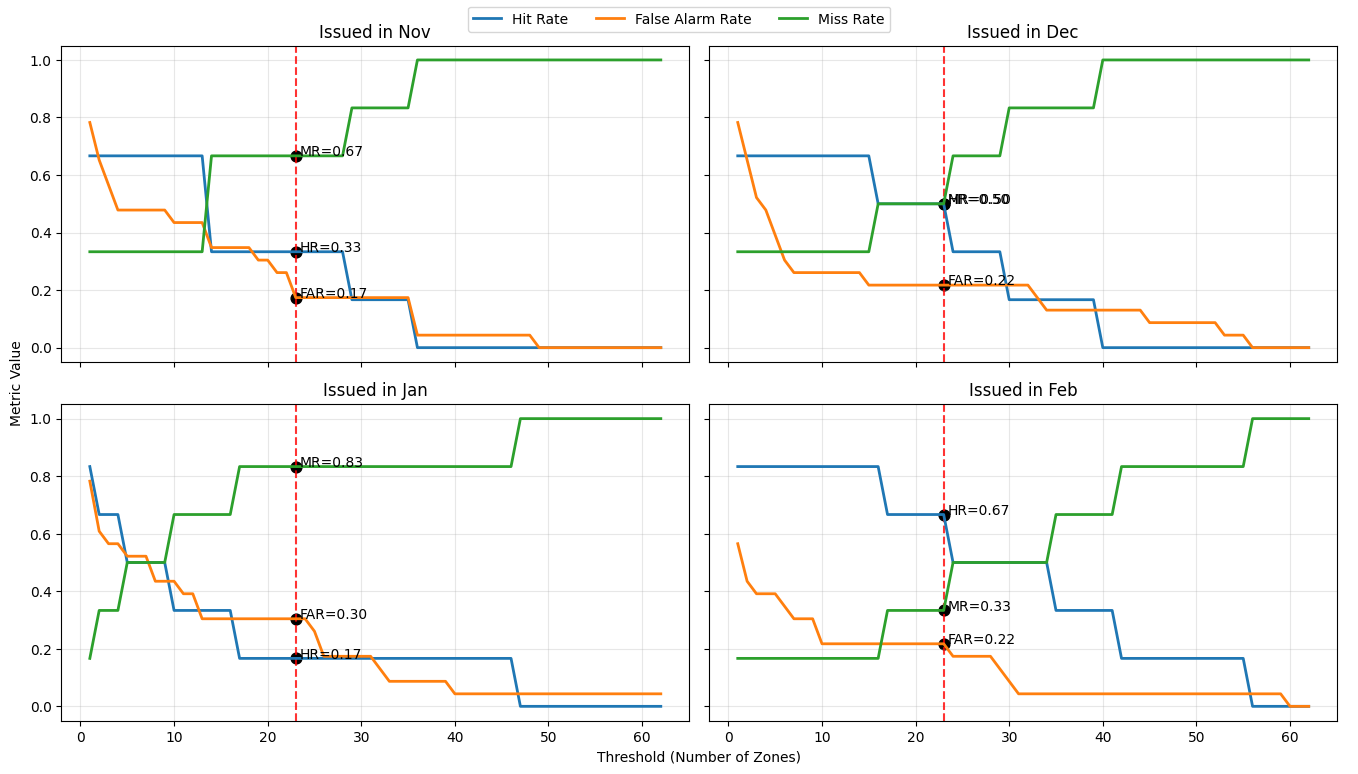

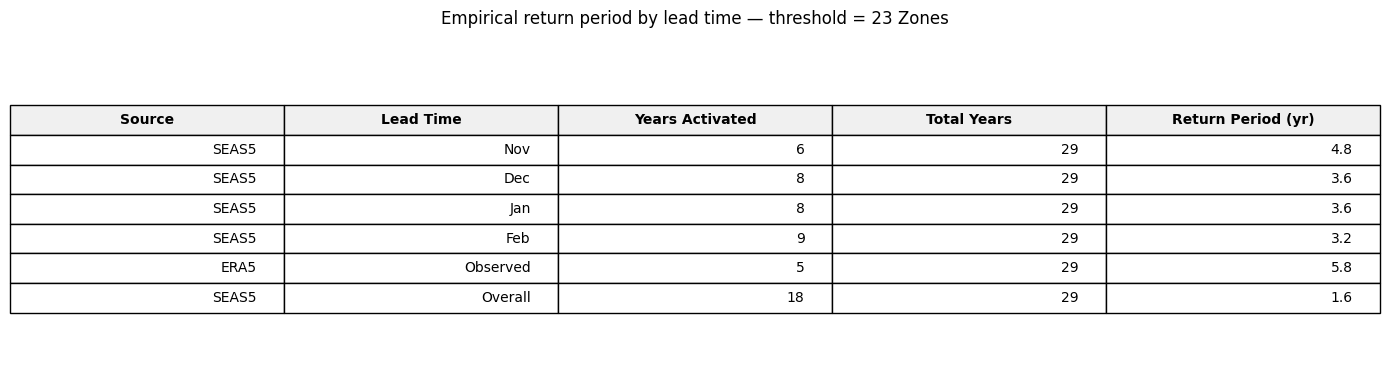

,year,ERA5 Rainfall (mm),Zones ≥ 5-Year RP LT-4 (Nov),Zones ≥ 5-Year RP LT-3 (Dec),Zones ≥ 5-Year RP LT-2 (Jan),Zones ≥ 5-Year RP LT-1 (Feb),Zones ≥ 5-Year RP (Observed),CERF Allocations,People Affected
25,2022,192,,,,16,57,"11,999,748","24,100,000"
12,2009,233,,29,1,55,49,,"6,200,000"
3,2000,241,13,15,4,41,42,,
11,2008,247,35,23,9,23,44,,"6,400,000"
24,2021,276,13,39,46,34,26,"19,996,683","6,800,000"
14,2011,286,28,,16,,22,"14,598,379","4,805,679"
15,2012,288,13,1,24,28,18,,"1,000,000"
22,2019,290,,2,7,29,19,"9,998,667",
20,2017,291,1,33,1,,16,"10,000,000",
10,2007,298,35,32,7,5,9,,


In [ ]:
# Number of Zones
mam_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="MAM",
    season_months=[3, 4, 5],
    lead_time_map={11: 4, 12: 3, 1: 2, 2: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=23,
    N_events=6,
    pop_df=None,
)

mam_table

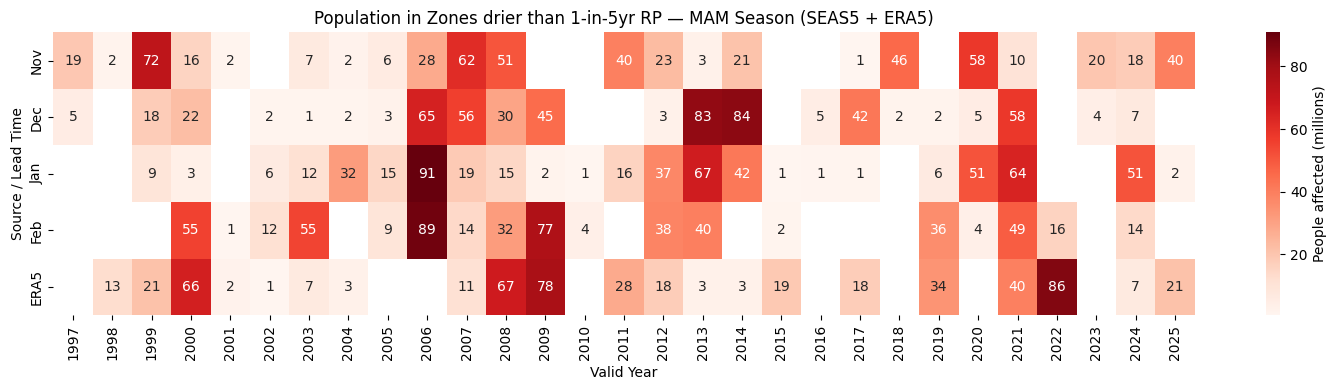

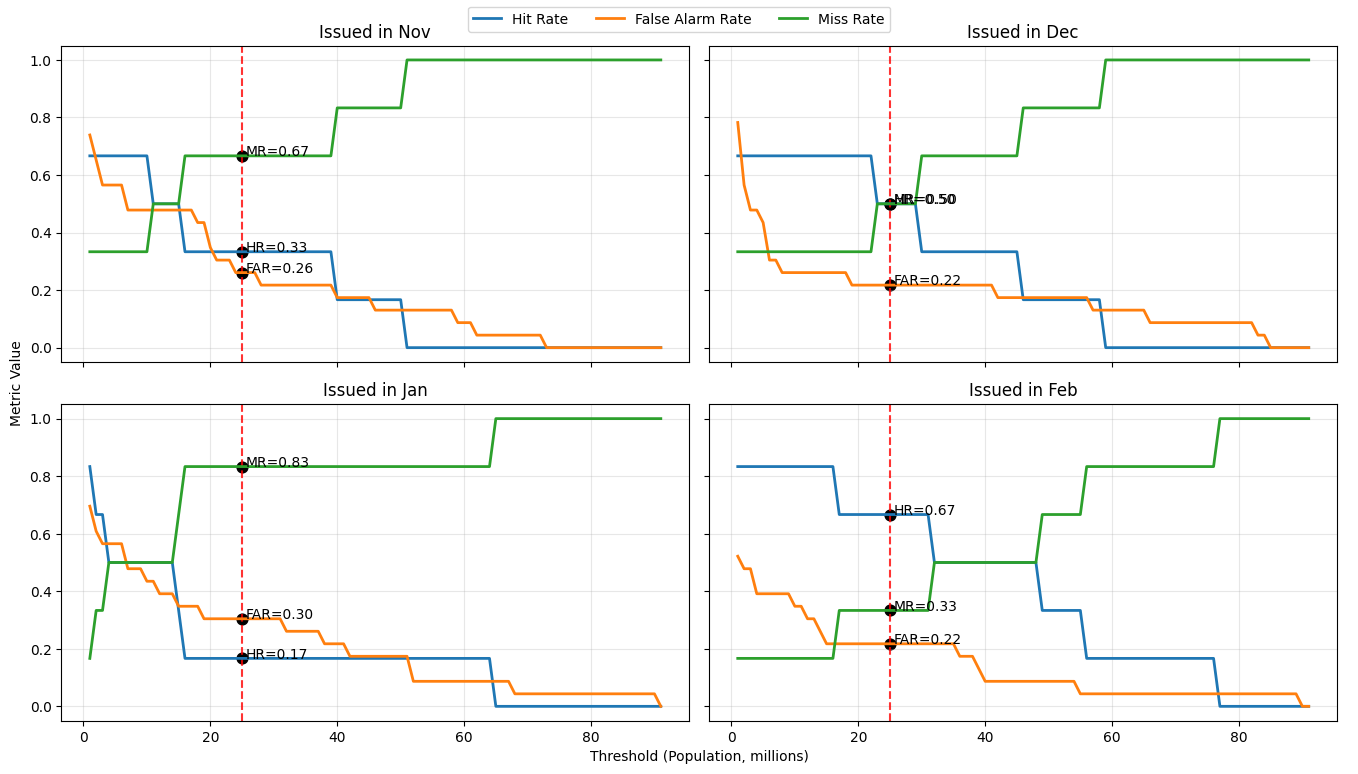

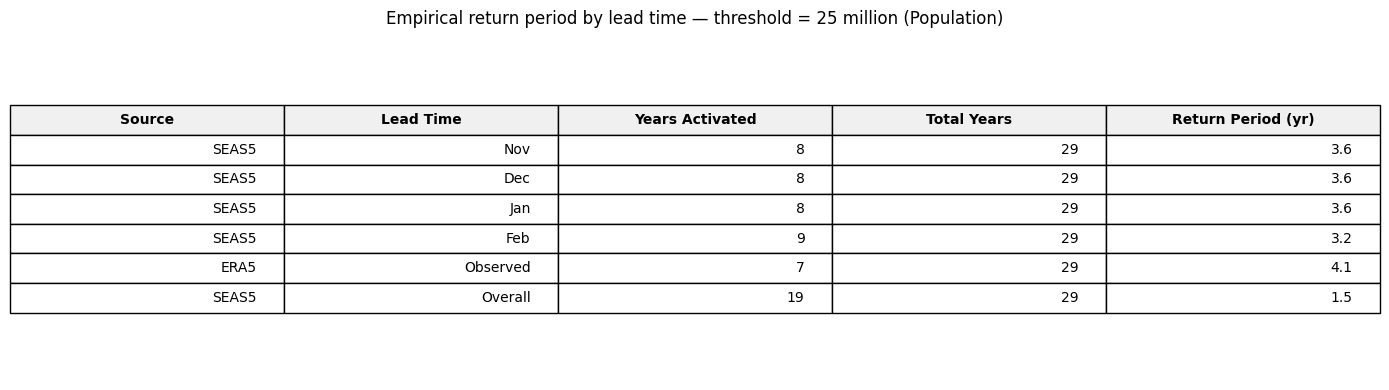

,year,ERA5 Rainfall (mm),Zones ≥ 5-Year RP LT-4 (Nov),Zones ≥ 5-Year RP LT-3 (Dec),Zones ≥ 5-Year RP LT-2 (Jan),Zones ≥ 5-Year RP LT-1 (Feb),Zones ≥ 5-Year RP (Observed),CERF Allocations,People Affected
25,2022,192,,,,"16,055,532","85,943,929","11,999,748","24,100,000"
12,2009,233,,"45,305,552","1,760,255","76,576,712","77,906,969",,"6,200,000"
3,2000,241,"15,662,508","22,380,482","3,480,636","55,281,117","66,044,516",,
11,2008,247,"50,871,697","29,778,436","14,960,012","31,873,216","67,369,340",,"6,400,000"
24,2021,276,"10,359,488","58,145,182","64,462,409","48,754,000","39,545,522","19,996,683","6,800,000"
14,2011,286,"39,505,664",,"15,871,049",,"28,052,457","14,598,379","4,805,679"
15,2012,288,"23,139,151","2,736,580","37,446,303","38,489,900","17,830,500",,"1,000,000"
22,2019,290,,"1,741,418","6,294,323","35,975,540","33,831,134","9,998,667",
20,2017,291,"763,506","41,971,982","1,340,059",,"17,865,853","10,000,000",
10,2007,298,"61,630,033","56,239,345","18,873,367","14,260,117","11,473,438",,


In [ ]:
# By Population
use_hnrp = False  # True or False
if use_hnrp:
    eth_adm2_pop = stratus.load_csv_from_blob(
        "ds-aa-eth-drought/processed/hnrp.csv",
        stage="dev",
        container_name="projects",
    )
else:
    eth_adm2_pop = stratus.load_csv_from_blob(
        "ds-aa-eth-drought/processed/eth_adm2_pop.csv",
        stage="dev",
        container_name="projects",
    )

mam_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="MAM",
    season_months=[3, 4, 5],
    lead_time_map={11: 4, 12: 3, 1: 2, 2: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=25,
    N_events=6,
    pop_df=eth_adm2_pop,
)

mam_table

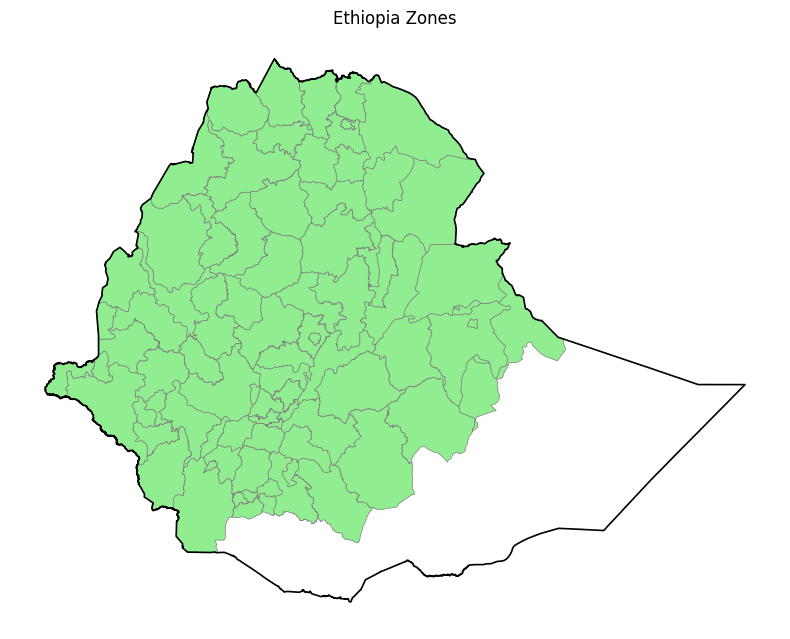

In [ ]:
season_csv = stratus.load_csv_from_blob(
    jjas_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    jjas_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(season_csv["adm2_pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

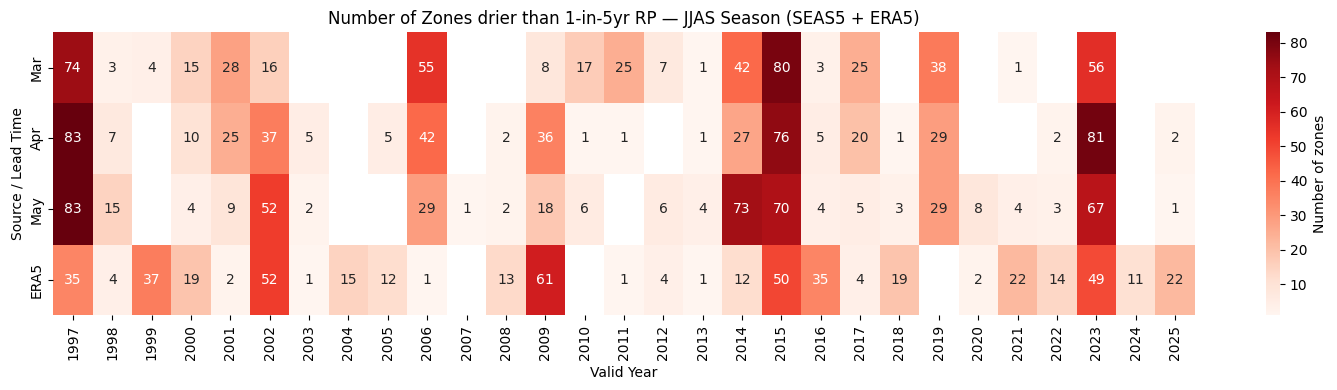

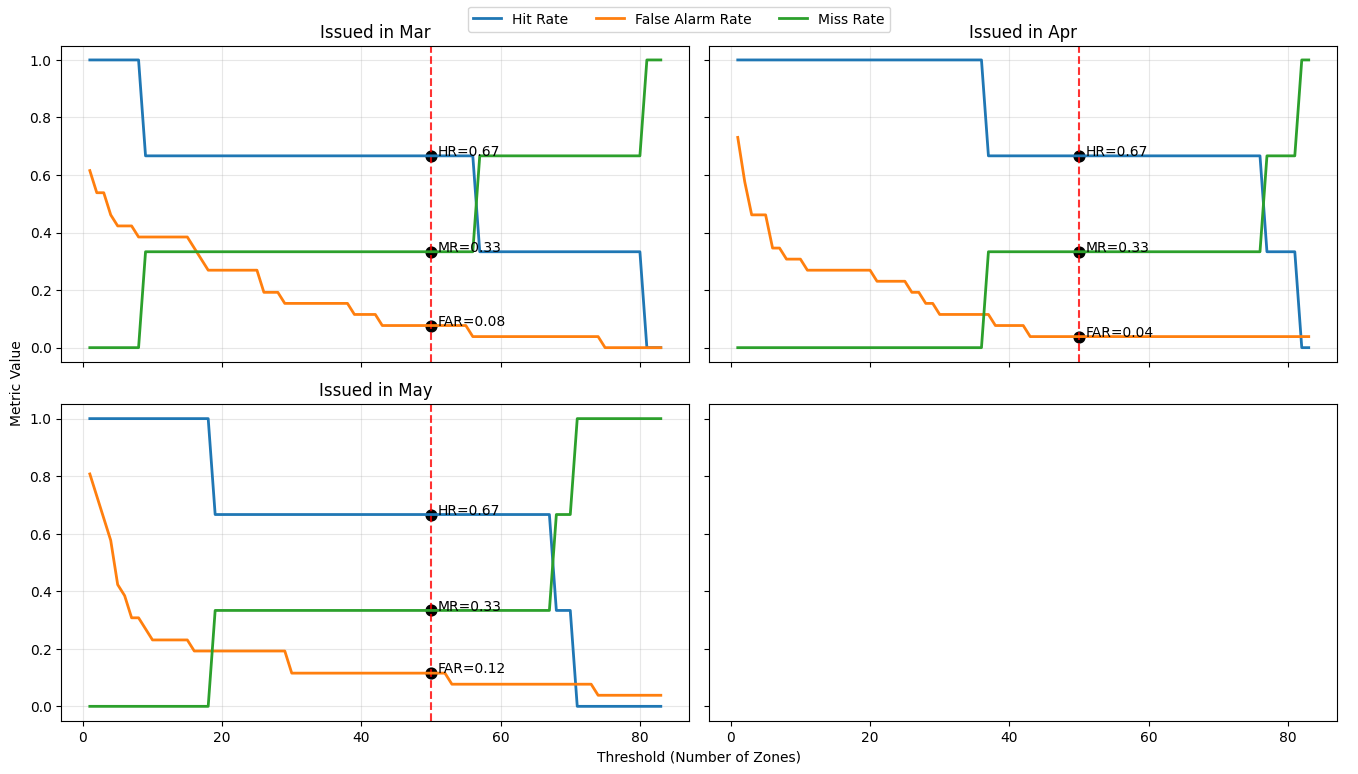

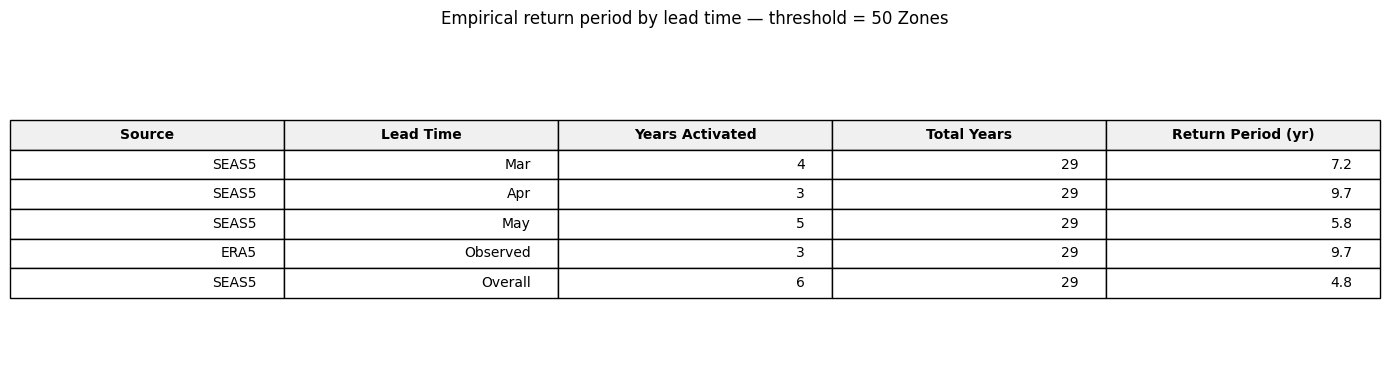

,year,ERA5 Rainfall (mm),Zones ≥ 5-Year RP LT-3 (Mar),Zones ≥ 5-Year RP LT-2 (Apr),Zones ≥ 5-Year RP LT-1 (May),Zones ≥ 5-Year RP (Observed),CERF Allocations,People Affected
12,2009,654,8,36,18,61,,"6,200,000"
26,2023,656,56,81,67,49,"17,000,001",
18,2015,660,80,76,70,50,,"10,200,000"
5,2002,666,16,37,52,52,,
0,1997,690,74,83,83,35,,
24,2021,691,1,,4,22,,"6,800,000"
19,2016,698,3,5,4,35,,
2,1999,703,4,,,37,,
28,2025,720,,2,1,22,,
7,2004,720,,,,15,,


In [ ]:
jjas_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="JJAS",
    season_months=[6, 7, 8, 9],
    lead_time_map={3: 3, 4: 2, 5: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=50,
    N_events=3,
    pop_df=None,
)

jjas_table

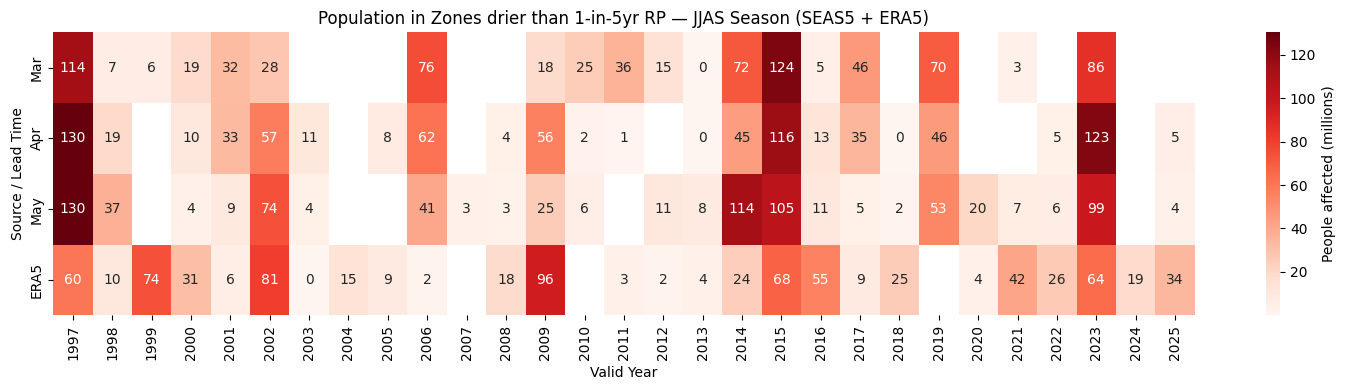

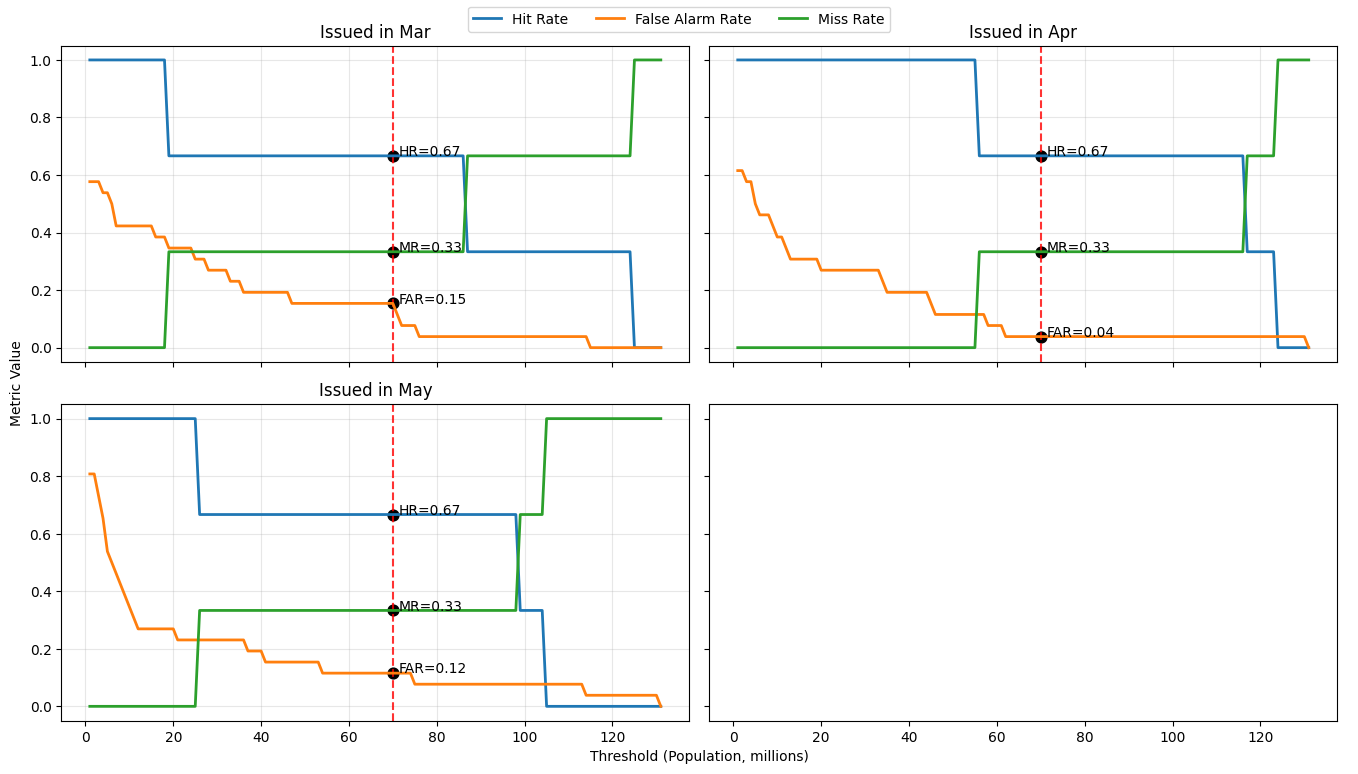

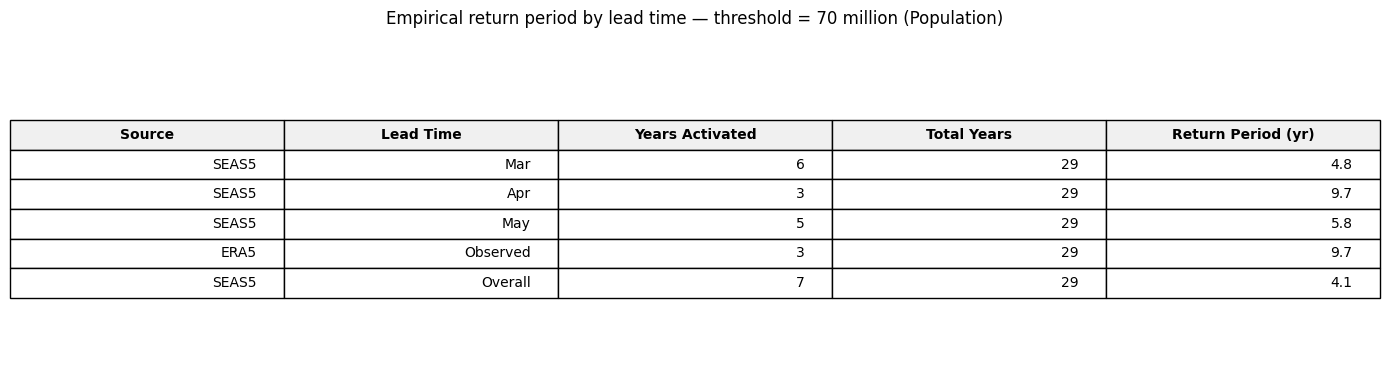

In [ ]:
jjas_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="JJAS",
    season_months=[6, 7, 8, 9],
    lead_time_map={3: 3, 4: 2, 5: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=70,
    N_events=3,
    pop_df=eth_adm2_pop,
)

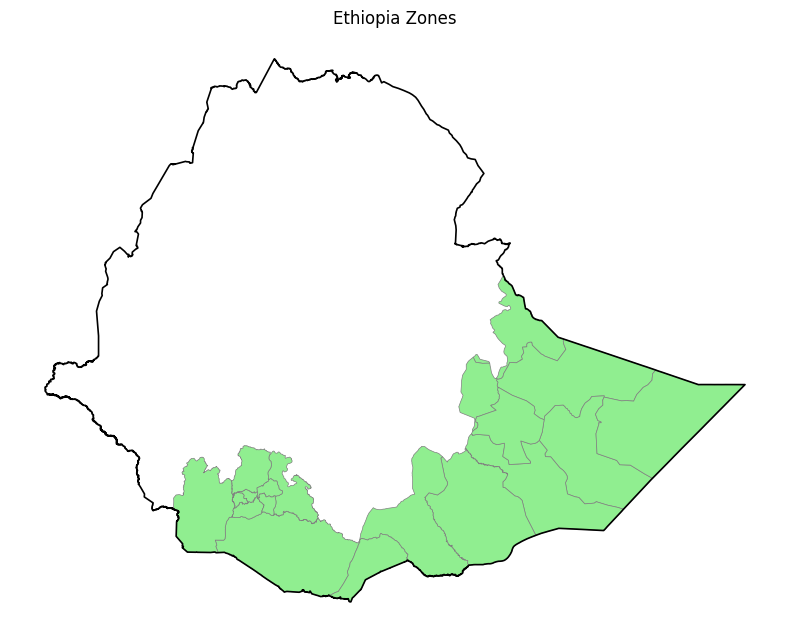

In [ ]:
season_csv = stratus.load_csv_from_blob(
    ond_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    ond_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
# plot the admins
fig, ax = plt.subplots(figsize=(8, 8))
eth_adm2[eth_adm2["adm2_src"].isin(season_csv["adm2_pcode"])].plot(
    ax=ax, edgecolor="grey", facecolor="lightgreen", linewidth=0.5
)
eth_adm0.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("Ethiopia Zones")
ax.set_axis_off()

plt.tight_layout()
plt.show()

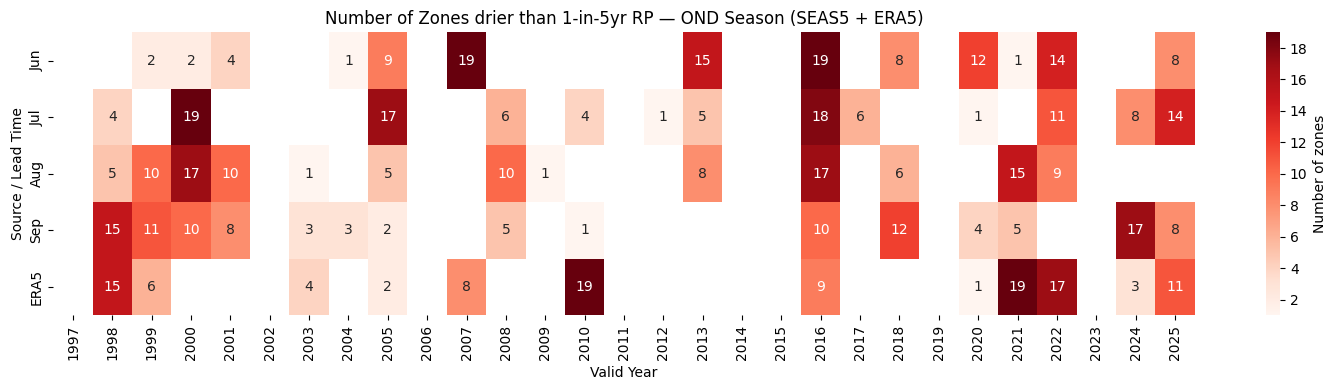

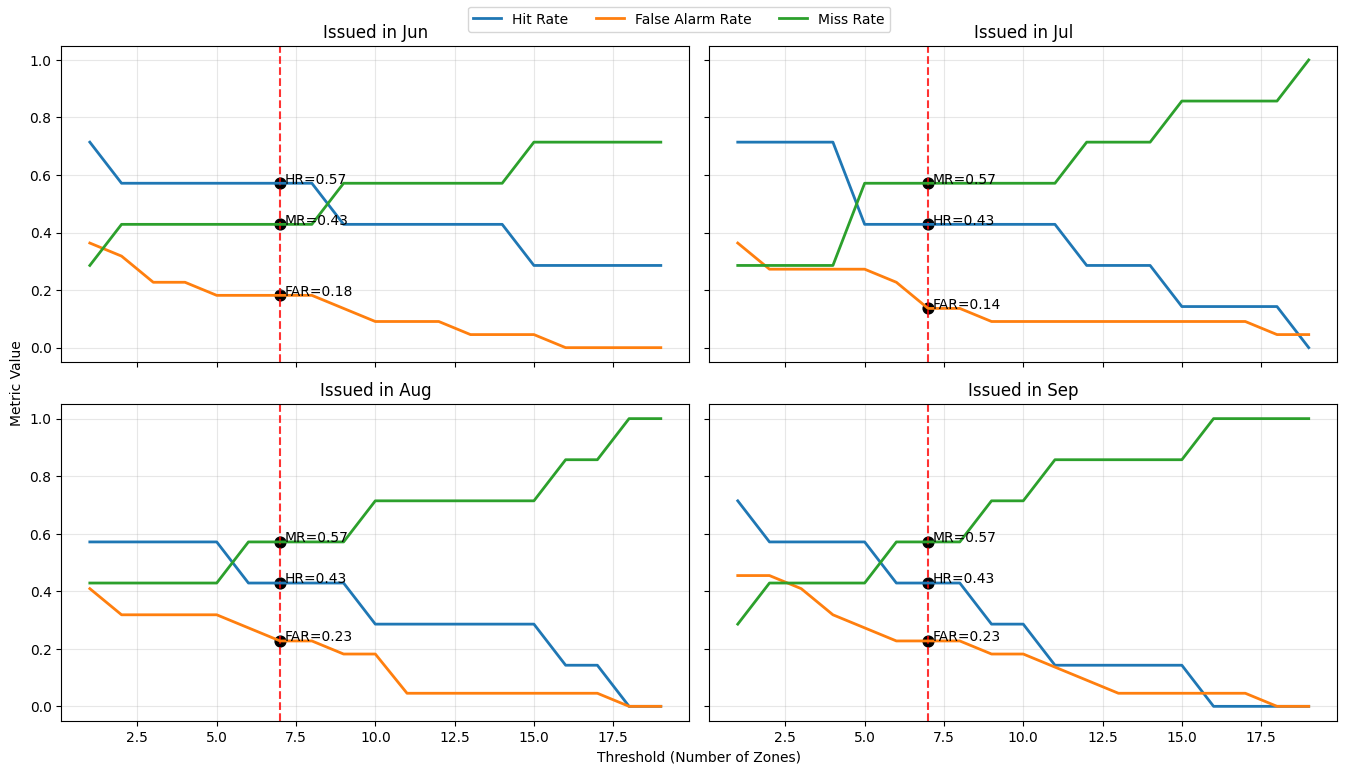

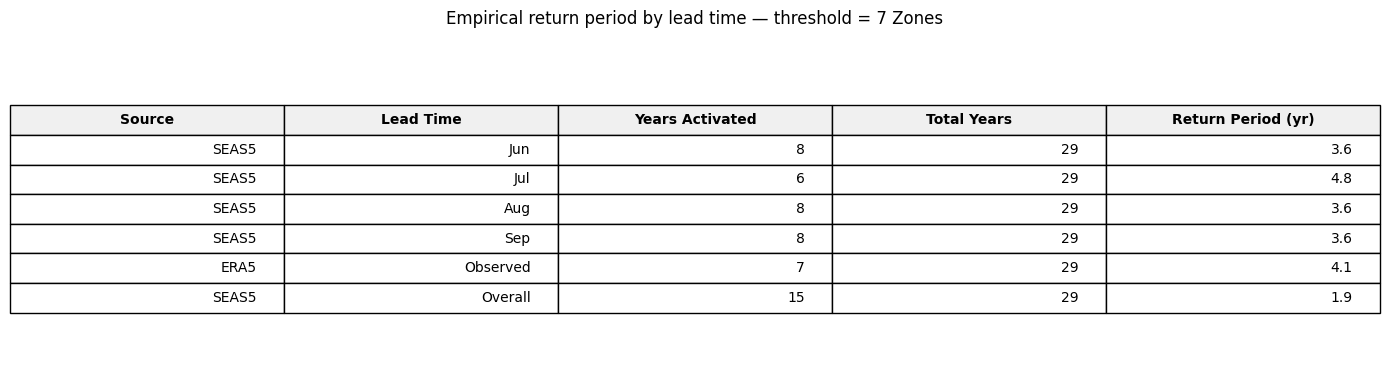

,year,ERA5 Rainfall (mm),Zones ≥ 5-Year RP LT-4 (Jun),Zones ≥ 5-Year RP LT-3 (Jul),Zones ≥ 5-Year RP LT-2 (Aug),Zones ≥ 5-Year RP LT-1 (Sep),Zones ≥ 5-Year RP (Observed),CERF Allocations,People Affected
24,2021,72,1,,15,5,19,"4,987,750","6,800,000"
13,2010,85,,4,,1,19,,
25,2022,95,14,11,9,,17,,"24,100,000"
1,1998,104,,4,5,15,15,,
28,2025,111,8,14,,8,11,,
19,2016,121,19,18,17,10,9,"18,512,690",
10,2007,131,19,,,,8,"19,999,594",
2,1999,134,2,,10,11,6,,
8,2005,144,9,17,5,2,2,"3,978,239","2,600,000"
6,2003,156,,,1,3,4,,"12,600,000"


In [ ]:
ond_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="OND",
    season_months=[10, 11, 12],
    lead_time_map={6: 4, 7: 3, 8: 2, 9: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=7,
    N_events=7,
    pop_df=None,
)

ond_table

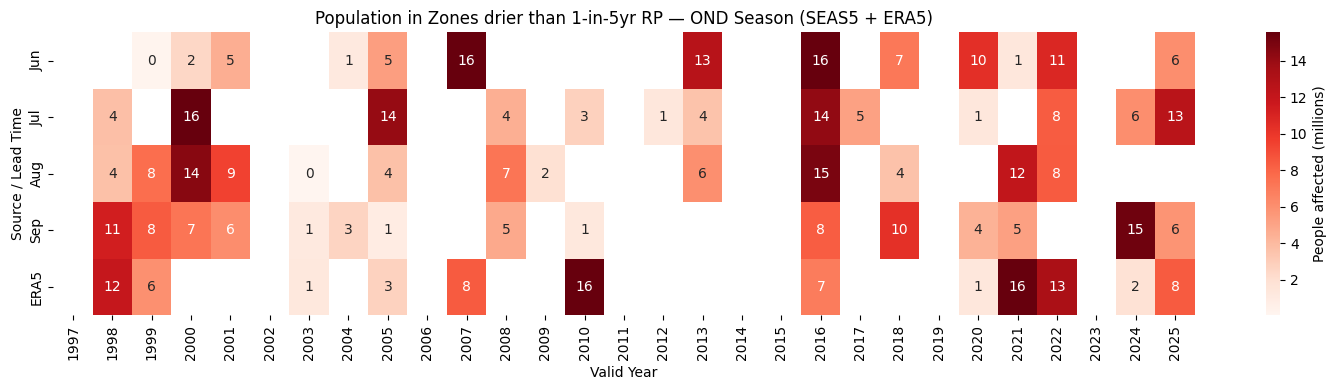

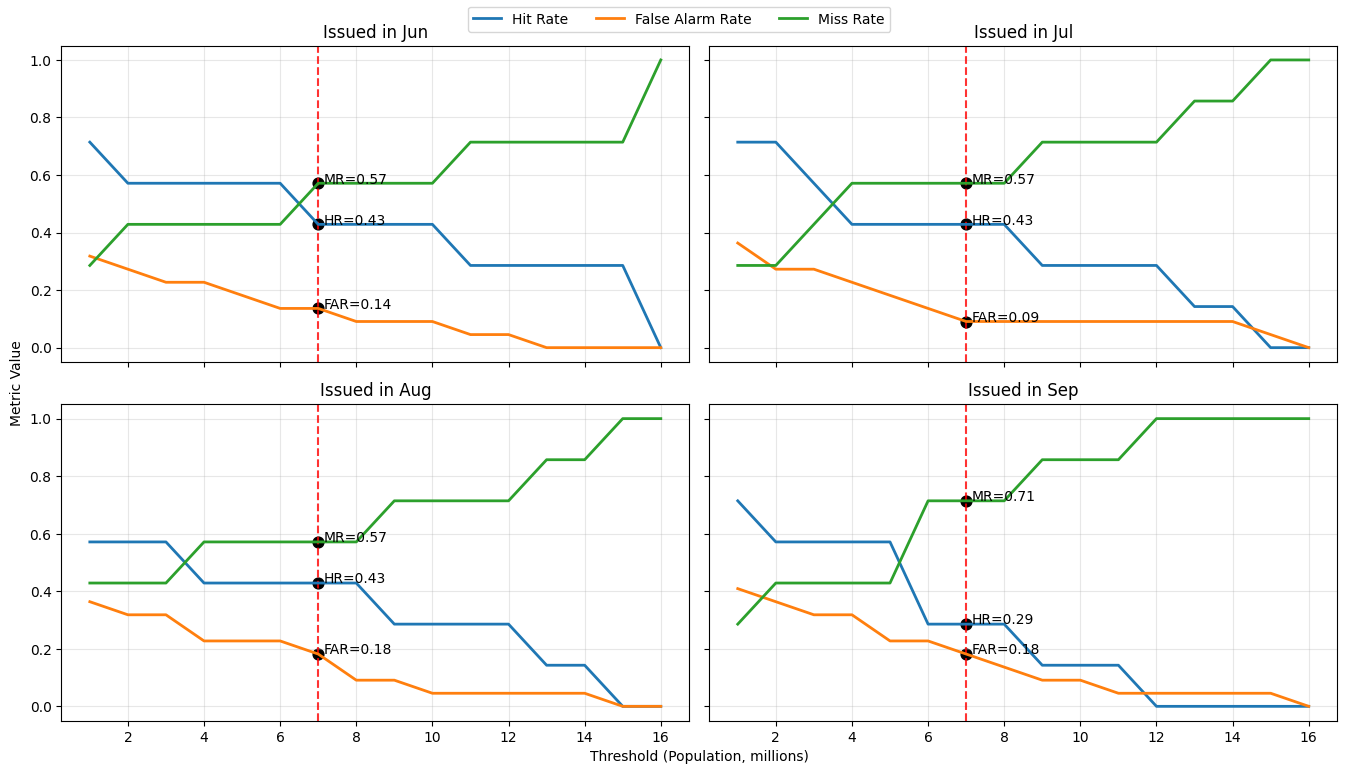

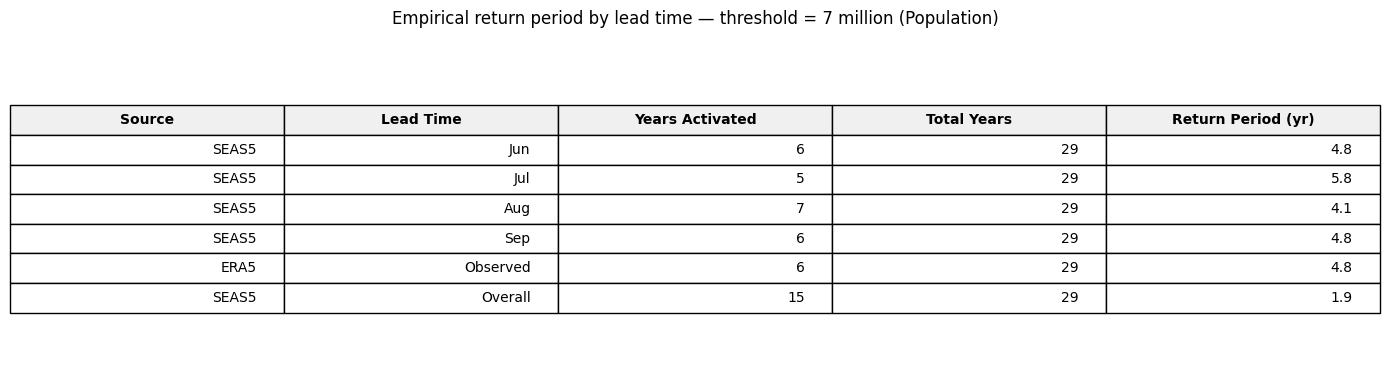

,year,ERA5 Rainfall (mm),Zones ≥ 5-Year RP LT-4 (Jun),Zones ≥ 5-Year RP LT-3 (Jul),Zones ≥ 5-Year RP LT-2 (Aug),Zones ≥ 5-Year RP LT-1 (Sep),Zones ≥ 5-Year RP (Observed),CERF Allocations,People Affected
24,2021,72,"1,382,406",,"12,194,309","5,213,792","15,552,288","4,987,750","6,800,000"
13,2010,85,,"2,809,348",,"1,297,212","15,552,288",,
25,2022,95,"10,844,330","8,386,157","8,462,645",,"13,275,476",,"24,100,000"
1,1998,104,,"3,736,723","3,645,106","11,318,794","11,922,678",,
28,2025,111,"6,053,887","12,557,913",,"5,788,258","8,428,504",,
19,2016,121,"15,552,288","14,169,882","14,905,922","8,305,225","6,907,778","18,512,690",
10,2007,131,"15,552,288",,,,"8,456,845","19,999,594",
2,1999,134,"184,193",,"7,562,733","8,428,504","5,961,637",,
8,2005,144,"5,293,233","14,092,376","3,670,168","902,155","2,722,465","3,978,239","2,600,000"
6,2003,156,,,"52,224","1,173,172","1,311,821",,"12,600,000"


In [ ]:
ond_table = build_season_table(
    seas5_data=seas5_data,
    validation_csv=validation_csv,
    era5_data=era5_data,
    season_name="OND",
    season_months=[10, 11, 12],
    lead_time_map={6: 4, 7: 3, 8: 2, 9: 1},
    rp_threshold=5,
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=7,
    N_events=7,
    pop_df=eth_adm2_pop,
)

ond_table